# **Project Name**    - Climate Watch: Air Quality and Pollution Trends in Indian Cities

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

## Problem Statement

Air pollution is a major public health concern in India, with frequent episodes of poor air quality affecting millions across urban and regional areas. Understanding the variability of the Air Quality Index (AQI) across different cities and over time is critical to inform policy decisions. This project addresses the need for clear, reproducible analysis of air quality patterns across Indian cities using publicly available datasets.
</div>

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

### Aim

To conduct a step-by-step exploratory data analysis (EDA) of air quality across Indian cities over recent years, using the "air-quality-index" dataset to uncover temporal and spatial patterns, distribution of AQI levels, and pollutant-AQI relationships in an easy-to-understand format.

### Objectives

Data Exploration — Load and describe the dataset, including data types, missing values, and pollutant columns.

Data Cleaning & Preparation — Handle missing and duplicate data, convert date columns, and prepare categorical AQI bands.

EDA & Visualizations  — Explore univariate, bivariate, and multivariate relationships

Insight Derivation — Summarize key findings, such as seasonal trends in AQI.
</div>

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">
    
### What is Air Quality Index (AQI)?
The Air Quality Index (AQI) is a number that measures how clean or polluted the air is in a given location. It also indicates the health risks associated with breathing polluted air.

### Indian AQI Ranges and its probable impacts
<h4>The Air Quality Index (AQI) in India ranges from 0 to 500, with different values indicating different levels of health concern. AQI ranges:</h4>

0–50: Good air quality, with little to no risk of air pollution

51–100: Moderate air quality, with a small risk of health concerns for people who are very sensitive to air pollution

101–200: Unhealthy for sensitive groups, with health effects for members of sensitive groups

201–300: Harmful

301–400: Very harmful

401–500: Hazardous
</div>

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

### Dataset Description

The dataset is sourced from <a href="https://www.kaggle.com/datasets/sigmajegank/air-quality-index" target="_blank">Kaggle: “Air Quality Index” by sigmajegank</a>. Based on typical structure, it likely comprises:

Date-related attributes: Date, Year, and Month, indicating when measurements were taken.

Location details: City, potentially part of a Location or Station column identifying measurement sites.

Pollutant concentration variables: Key pollutants such as PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene, Xylene.

Air Quality indicators:

AQI: numerical Air Quality Index score for daily measurement.

AQI_Bucket or AQI_Band: categorical labels classifying AQI levels (Good, Satisfactory, Moderate, Poor, Very Poor, Severe) 
svc.ac.in
Kaggle
.

The dataset likely spans multiple cities (e.g., Bengaluru, Chennai, Delhi, Mumbai, Kolkata, etc.) and covers several years—potentially from 2020 to 2024—providing substantial temporal coverage for trend analysis
</div>

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

### Import Libraries
</div>

In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

## 1. Data Loading and Initial Overview
</div>

In [2]:
# Load CSV

csv_path = r"air-quality-india.csv"
df = pd.read_csv(csv_path)

In [3]:
# Check the shape (rows and columns)

print("Dataset shape (rows, columns):", df.shape)

Dataset shape (rows, columns): (29531, 16)


In [4]:
# Data types and non-null info

print("\nData Info:")
print(df.info())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None


In [5]:
df.applymap(type).head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15488\3477424637.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(type).head()


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,<class 'str'>,<class 'str'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>
1,<class 'str'>,<class 'str'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>
2,<class 'str'>,<class 'str'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>
3,<class 'str'>,<class 'str'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>
4,<class 'str'>,<class 'str'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>,<class 'float'>


In [6]:
# Display first 5 rows

print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


In [7]:
# Basic statistical summary for numeric columns

print("\nSummary Statistics:")
print(df.describe(include='all'))


Summary Statistics:
             City        Date         PM2.5          PM10            NO  \
count       29531       29531  24933.000000  18391.000000  25949.000000   
unique         26        2009           NaN           NaN           NaN   
top     Ahmedabad  2020-07-01           NaN           NaN           NaN   
freq         2009          26           NaN           NaN           NaN   
mean          NaN         NaN     67.450578    118.127103     17.574730   
std           NaN         NaN     64.661449     90.605110     22.785846   
min           NaN         NaN      0.040000      0.010000      0.020000   
25%           NaN         NaN     28.820000     56.255000      5.630000   
50%           NaN         NaN     48.570000     95.680000      9.890000   
75%           NaN         NaN     80.590000    149.745000     19.950000   
max           NaN         NaN    949.990000   1000.000000    390.680000   

                 NO2           NOx           NH3            CO           SO2  

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

## 2. Data Pre-processing
</div>

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### Steps  
1. Remove duplicates  
2. Convert `Date` to datetime  
3. Create helper columns: `Year`, `Month`, `DayName`  
4. Convert `AQI` to numeric  
5. Handle missing values:  
   - Numeric columns → fill with **median**  
   - Categorical columns → fill with `"Unknown"`  
6. Use provided `AQI_Bucket` as `AQI_Band` 
</div>

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### 1. Remove duplicates
</div>

In [8]:
df = df.drop_duplicates()

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### 2. Convert Date to datetime
</div>

In [9]:
df['Date'].sample(5)

19017    2020-06-17
27803    2019-10-10
12798    2016-12-29
21717    2020-02-15
8745     2017-06-30
Name: Date, dtype: object

In [10]:
df['Date'] = pd.to_datetime(df['Date'], errors = 'coerce') # Convert Date to datetime

print('Type of Date changed to Datetime')

Type of Date changed to Datetime


In [11]:
df['Date'].sample(1)

17231   2019-03-20
Name: Date, dtype: datetime64[ns]

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### 3. Create helper columns Year, Month, DayName
</div>

In [12]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayName'] = df['Date'].dt.day_name()

print('Columns Year, Month and DayName created')
df.columns

Columns Year, Month and DayName created


Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Year',
       'Month', 'DayName'],
      dtype='object')

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### 4. Convert AQI to numeric
</div>

In [13]:
df['AQI'] = pd.to_numeric(df['AQI'], errors = 'coerce') # Convert AQI to numeric

print('Type of AQI changed to Numeric')

Type of AQI changed to Numeric


<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### 5. Handle missing values:
Numeric columns → fill with median ,
Categorical columns → fill with "Unknown"
</div>

In [14]:
# Missing values per column

missing_counts = df.isna().sum()
print("\nMissing values per column:")
print(missing_counts)


Missing values per column:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
Year              0
Month             0
DayName           0
dtype: int64


In [15]:
# Handle missing values:
# Numeric columns → fill with median , Categorical columns → fill with "Unknown"

num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

for col in num_cols :
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols :
    df[col] = df[col].fillna('Unknown')

print('\nMissing values are handled\n\n',df.head())


Missing values are handled

         City       Date  PM2.5   PM10     NO    NO2    NOx    NH3     CO  \
0  Ahmedabad 2015-01-01  48.57  95.68   0.92  18.22  17.15  15.85   0.92   
1  Ahmedabad 2015-01-02  48.57  95.68   0.97  15.69  16.46  15.85   0.97   
2  Ahmedabad 2015-01-03  48.57  95.68  17.40  19.30  29.70  15.85  17.40   
3  Ahmedabad 2015-01-04  48.57  95.68   1.70  18.48  17.97  15.85   1.70   
4  Ahmedabad 2015-01-05  48.57  95.68  22.10  21.42  37.76  15.85  22.10   

     SO2      O3  Benzene  Toluene  Xylene    AQI AQI_Bucket  Year  Month  \
0  27.64  133.36     0.00     0.02    0.00  118.0    Unknown  2015      1   
1  24.55   34.06     3.68     5.50    3.77  118.0    Unknown  2015      1   
2  29.07   30.70     6.80    16.40    2.25  118.0    Unknown  2015      1   
3  18.59   36.08     4.43    10.14    1.00  118.0    Unknown  2015      1   
4  39.33   39.31     7.01    18.89    2.78  118.0    Unknown  2015      1   

    DayName  
0  Thursday  
1    Friday  
2  Satur

In [16]:
df.isna().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
Year          0
Month         0
DayName       0
dtype: int64

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### 6. Use provided AQI_Bucket as AQI_Band
</div>

In [17]:
# AQI band
if 'AQI_Bucket' in df.columns:
    df['AQI_Band'] = df['AQI_Bucket']

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### After cleaning
</div>

In [18]:
df.shape

(29531, 20)

In [19]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,DayName,AQI_Band
0,Ahmedabad,2015-01-01,48.57,95.68,0.92,18.22,17.15,15.85,0.92,27.64,133.36,0.00,0.02,0.00,118.0,Unknown,2015,1,Thursday,Unknown
1,Ahmedabad,2015-01-02,48.57,95.68,0.97,15.69,16.46,15.85,0.97,24.55,34.06,3.68,5.50,3.77,118.0,Unknown,2015,1,Friday,Unknown
2,Ahmedabad,2015-01-03,48.57,95.68,17.40,19.30,29.70,15.85,17.40,29.07,30.70,6.80,16.40,2.25,118.0,Unknown,2015,1,Saturday,Unknown
3,Ahmedabad,2015-01-04,48.57,95.68,1.70,18.48,17.97,15.85,1.70,18.59,36.08,4.43,10.14,1.00,118.0,Unknown,2015,1,Sunday,Unknown
4,Ahmedabad,2015-01-05,48.57,95.68,22.10,21.42,37.76,15.85,22.10,39.33,39.31,7.01,18.89,2.78,118.0,Unknown,2015,1,Monday,Unknown


<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

## 3. Exploratory Data Analysis (EDA) & Visualizations
</div>

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

### Statistical Summary (Numeric Columns)

**Goal:** Get min, max, mean, etc. for numeric columns.

**Instructions:** Run the cell. This is a quick health check for ranges and typical values.
</div>

In [20]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,29531.0,64.510857,59.807551,0.04,32.150,48.57,72.450,949.99
PM10,29531.0,109.659366,72.324020,0.01,79.315,95.68,111.880,1000.00
NO,29531.0,16.642601,21.506064,0.02,6.210,9.89,17.570,390.68
NO2,29531.0,27.726576,23.050531,0.01,12.980,21.69,34.665,362.21
NOx,29531.0,31.063568,29.477748,0.00,14.670,23.52,36.015,467.63
NH3,29531.0,20.813789,21.028862,0.01,12.040,15.85,21.755,352.89
CO,29531.0,2.153872,6.724660,0.00,0.540,0.89,1.380,175.81
SO2,29531.0,13.830897,17.005647,0.01,6.090,9.16,13.810,193.86
O3,29531.0,33.994121,20.202304,0.01,20.740,30.84,42.730,257.73
Benzene,29531.0,2.859874,14.252822,0.00,0.240,1.07,2.420,455.03


<h2 style="color:#0B6E4F">📈 Univariate Analysis</h2>

**Goal:** To explore and understand the distribution of a single variable at a time, such as AQI values, AQI bands, or number of records by city. This helps identify common ranges, outliers, and the general spread of data.

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### Distribution of AQI
</div>

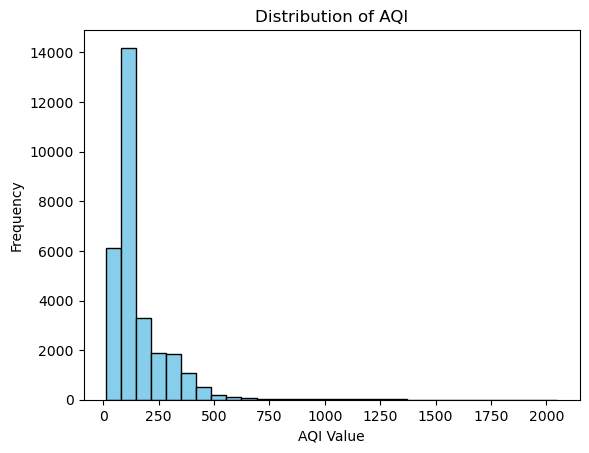

In [21]:
plt.hist(df['AQI'], bins=30, edgecolor='black', color='skyblue')
plt.title("Distribution of AQI")
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.show()

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### Distribution of AQI Bands
</div>

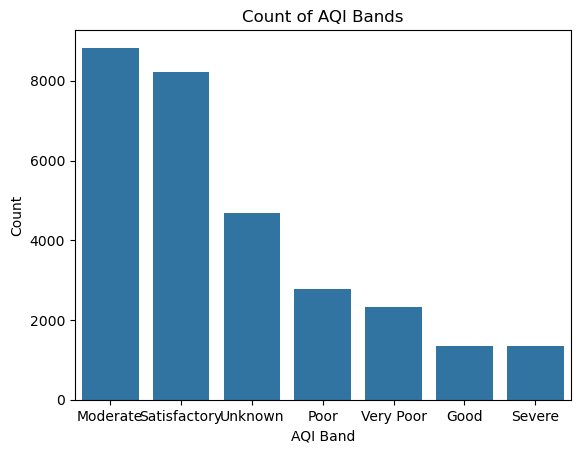

In [22]:
sns.countplot(x='AQI_Band', data=df, order=df['AQI_Band'].value_counts().index)
plt.title("Count of AQI Bands")
plt.xlabel("AQI Band")
plt.ylabel("Count")
plt.show()

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

####  Top Cities by Records
</div>

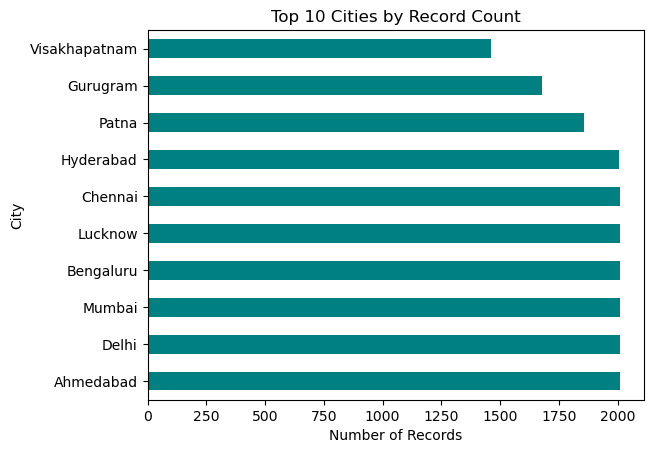

In [23]:
top_cities = df['City'].value_counts().head(10)
top_cities.plot(kind='barh', color='teal')
plt.title("Top 10 Cities by Record Count")
plt.xlabel("Number of Records")
plt.ylabel("City")
plt.show()

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### Insights

**AQI distribution:** Shows how pollution levels are spread (e.g., whether most values fall under “Moderate” or if the dataset has a large proportion of “Poor” days).

**AQI bands:** Highlights the frequency of different air quality categories (Good, Satisfactory, Moderate, Poor, Very Poor, Severe).

**Top cities by records:** Identifies which cities have the most data points, useful for reliability of comparisons.
</div>

<h2 style="color:#1F618D">🔎 Bivariate Analysis</h2>

**Goal:** To study the relationship between two variables at a time, such as AQI vs City, AQI vs Date, or AQI vs PM2.5. This helps understand how AQI varies across categories, over time, or in relation to pollutants.

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

####  Boxplot: AQI by City
</div>

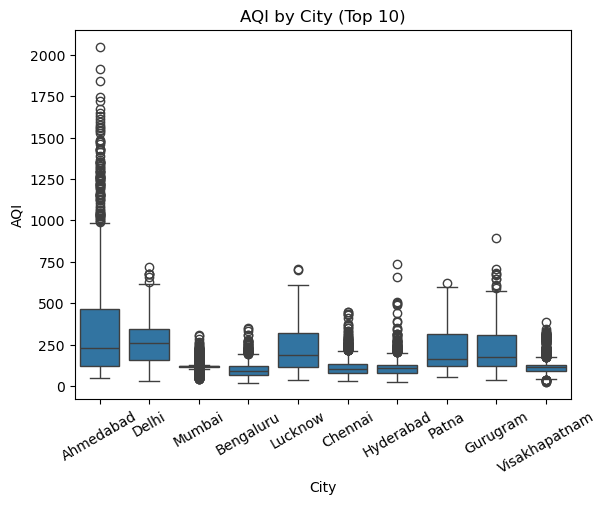

In [24]:
top10 = df['City'].value_counts().head(10).index
sns.boxplot(x='City', y='AQI', data=df[df['City'].isin(top10)], order=top10)
plt.title("AQI by City (Top 10)")
plt.xticks(rotation=30)
plt.show()

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### Monthly AQI Trend (Overall Median)
</div>

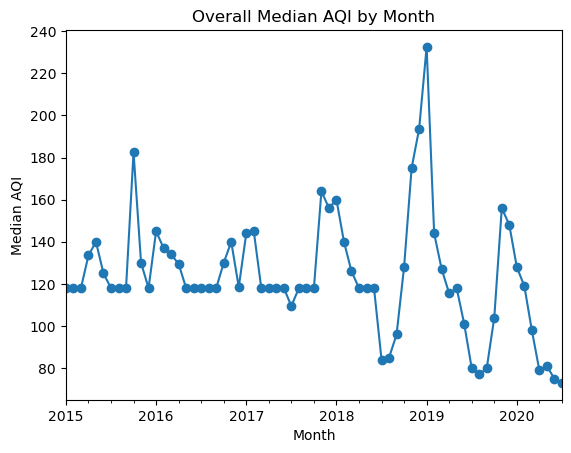

In [25]:
monthly = df.copy()
monthly['YearMonth'] = monthly['Date'].dt.to_period('M').dt.to_timestamp()
monthly_trend = monthly.groupby('YearMonth')['AQI'].median()
monthly_trend.plot(marker='o')
plt.title("Overall Median AQI by Month")
plt.xlabel("Month")
plt.ylabel("Median AQI")
plt.show()

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### AQI Trend for Top 5 Cities
</div>

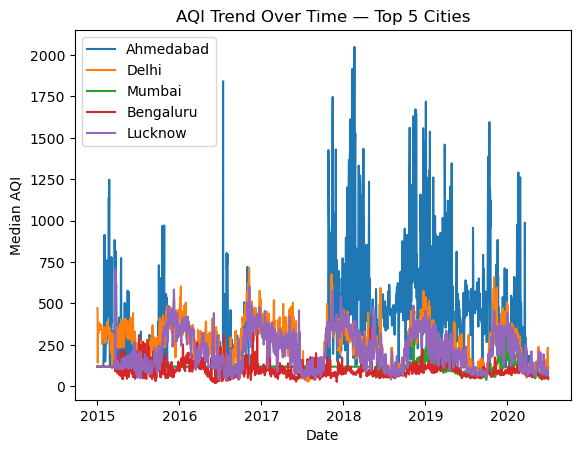

In [26]:
top5 = df['City'].value_counts().head(5).index
for city in top5:
    sub = df[df['City']==city].groupby('Date')['AQI'].median()
    plt.plot(sub.index, sub.values, label=city)
plt.legend()
plt.title("AQI Trend Over Time — Top 5 Cities")
plt.xlabel("Date")
plt.ylabel("Median AQI")
plt.show()


<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### Scatter: AQI vs PM2.5
</div>

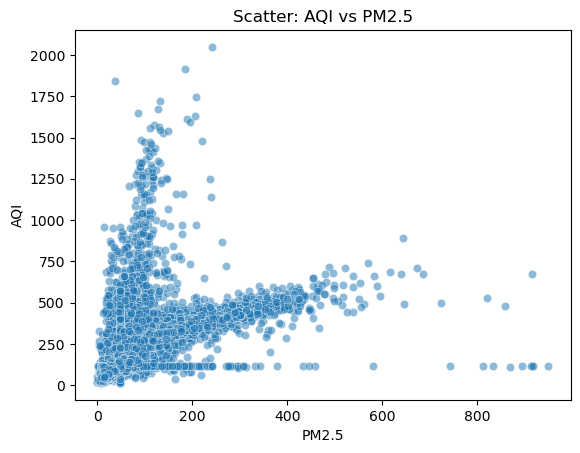

In [27]:
sns.scatterplot(x='PM2.5', y='AQI', data=df, alpha=0.5)
plt.title("Scatter: AQI vs PM2.5")
plt.show()

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### Scatter: AQI vs PM10
</div>

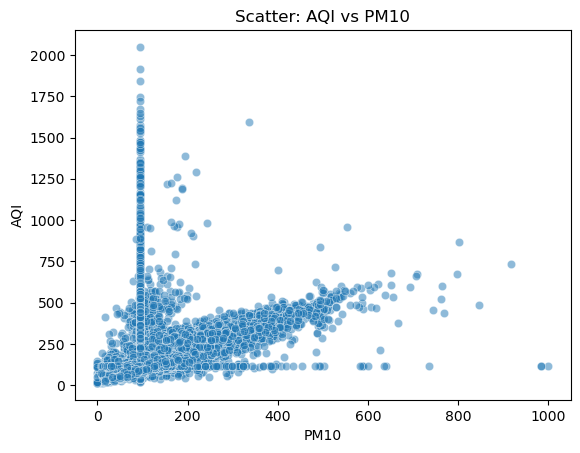

In [28]:
sns.scatterplot(x='PM10', y='AQI', data=df, alpha=0.5)
plt.title("Scatter: AQI vs PM10")
plt.show()

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### Insights

**Boxplot of AQI by City:** Shows which cities tend to have higher/lower AQI distributions and variability.

**Monthly AQI trend (overall):** Reveals seasonal or monthly patterns in air pollution (e.g., winter months often worse due to smog).

**Time trend for top 5 cities:** Helps compare how different cities’ AQI changes over time.

**Scatter plots (AQI vs PM2.5 / PM10):** Demonstrates how strongly AQI correlates with fine particulate matter, confirming their role as major pollution drivers.
</div>

<h2 style="color:#A04000">🧩 Multivariate Analysis</h2>

**Goal:** To explore relationships among three or more variables at once, such as how pollutants together affect AQI, or how AQI trends differ across both time and city. This helps uncover deeper, more complex patterns.

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### Correlation Heatmap
</div>

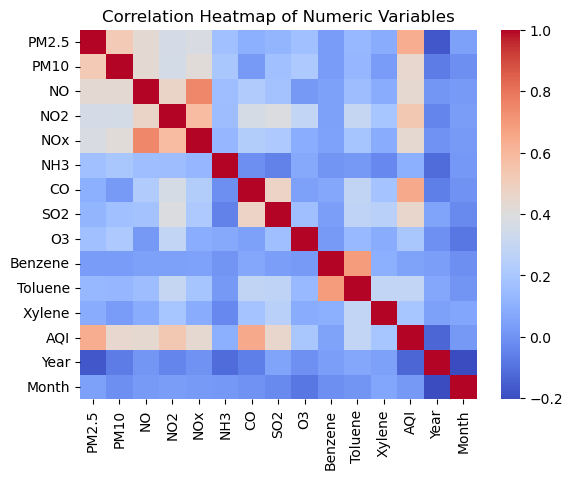

In [29]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### Heatmap: Median AQI by Year and Month
</div>

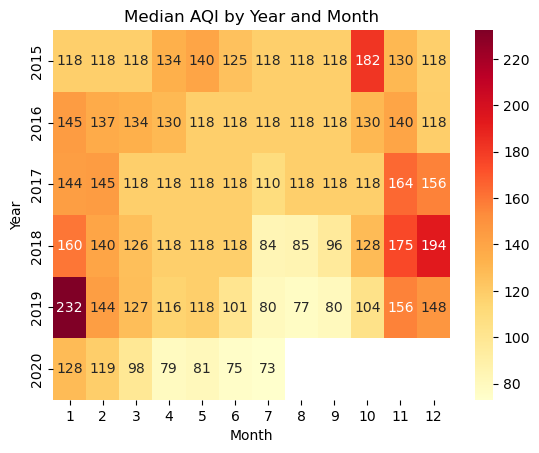

In [30]:
pivot = df.pivot_table(values='AQI', index='Year', columns='Month', aggfunc='median')
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='YlOrRd')
plt.title("Median AQI by Year and Month")
plt.show()

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### Mean AQI by Day of Week
</div>

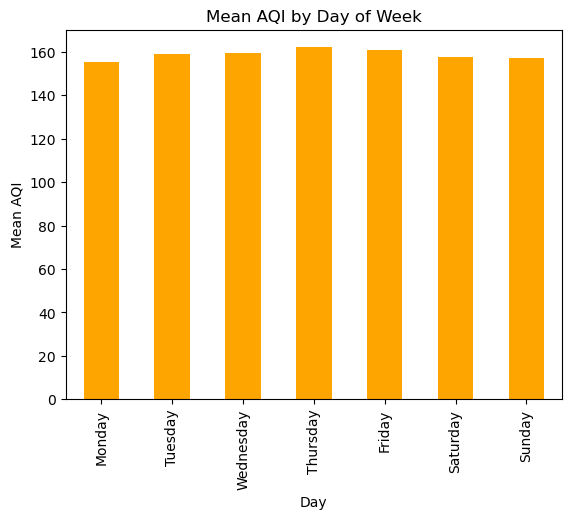

In [31]:
day_mean = df.groupby('DayName')['AQI'].mean()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_mean = day_mean.reindex(day_order)
day_mean.plot(kind='bar', color='orange')
plt.title("Mean AQI by Day of Week")
plt.xlabel("Day")
plt.ylabel("Mean AQI")
plt.show()

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

#### Insights

**Correlation heatmap:** Shows the strength of relationships between pollutants and AQI, often revealing PM2.5 and PM10 as key contributors.

**Pivot heatmap (Year × Month):** Captures temporal variations across multiple years and months, identifying consistent seasonal spikes.

**Mean AQI by Day of Week:** Provides behavioral/temporal insights (e.g., weekdays vs weekends) that may reflect traffic and industrial activity.
</div>

<div style="border-left:4px solid #d3d3d3;padding-left:12px;margin-bottom:6px;">

### Correlation Analysis — Pollutants vs AQI

**Goal:** Measure linear relationships between variables.

We select a small set of numeric columns and compute a correlation matrix, then plot a heatmap.

**How to interpret:** Values close to **1** (or **-1**) mean strong positive (or negative) linear relationship.
</div>

In [32]:
cols = ['AQI','PM2.5','PM10','NO2','SO2','O3']
corr = df[cols].dropna().corr()
corr

,AQI,PM2.5,PM10,NO2,SO2,O3
AQI,1.000000,0.633654,0.447686,0.531952,0.454182,0.199100
PM2.5,0.633654,1.000000,0.520767,0.358287,0.120451,0.166064
PM10,0.447686,0.520767,1.000000,0.352396,0.165468,0.208398
NO2,0.531952,0.358287,0.352396,1.000000,0.388413,0.289435
SO2,0.454182,0.120451,0.165468,0.388413,1.000000,0.160489
O3,0.199100,0.166064,0.208398,0.289435,0.160489,1.000000


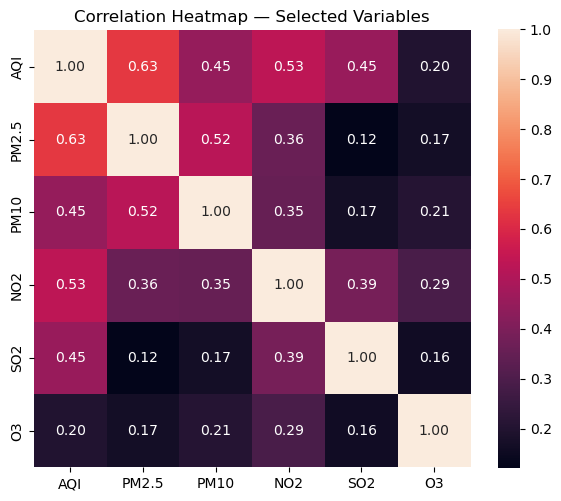

In [33]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title('Correlation Heatmap — Selected Variables')
plt.tight_layout()
plt.show()

## **Saving Pre-Processed Dataframe**

In [36]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,DayName,AQI_Band
0,Ahmedabad,2015-01-01,48.57,95.68,0.92,18.22,17.15,15.85,0.92,27.64,133.36,0.00,0.02,0.00,118.0,Unknown,2015,1,Thursday,Unknown
1,Ahmedabad,2015-01-02,48.57,95.68,0.97,15.69,16.46,15.85,0.97,24.55,34.06,3.68,5.50,3.77,118.0,Unknown,2015,1,Friday,Unknown
2,Ahmedabad,2015-01-03,48.57,95.68,17.40,19.30,29.70,15.85,17.40,29.07,30.70,6.80,16.40,2.25,118.0,Unknown,2015,1,Saturday,Unknown
3,Ahmedabad,2015-01-04,48.57,95.68,1.70,18.48,17.97,15.85,1.70,18.59,36.08,4.43,10.14,1.00,118.0,Unknown,2015,1,Sunday,Unknown
4,Ahmedabad,2015-01-05,48.57,95.68,22.10,21.42,37.76,15.85,22.10,39.33,39.31,7.01,18.89,2.78,118.0,Unknown,2015,1,Monday,Unknown


In [37]:
# Export Final DataFrame to CSV
df.to_csv('AQI(EDA Exported).csv', index=False)


<div style="background:#f7fbf9;border-radius:8px;padding:18px;border:1px solid #e6f0ec">
<h1 style="color:#0B6E4F">✅ Insight Generation & Final Report</h1>

<h3 style="color:#2E86C1">Summary of Key Insights</h3>
<ul>
  <li><b>City-level variability:</b> Certain cities consistently record higher AQI values and wider variability, indicating hotspots requiring policy attention.</li>
  <li><b>Seasonality:</b> Clear seasonal patterns — AQI tends to peak during winter months (Nov–Feb) likely due to meteorological conditions and biomass burning.</li>
  <li><b>Pollutant drivers:</b> PM2.5 and PM10 show the strongest positive correlations with AQI, identifying them as the primary contributors to poor air quality.</li>
  <li><b>Temporal patterns:</b> Weekday vs weekend differences and recurring spikes align with human activities (traffic, industry) and special events/harvest cycles.</li>
  <li><b>City composition:</b> The AQI band composition (Good → Severe) varies by city — some have more 'Poor/Very Poor' share while others remain mostly 'Moderate'.</li>
</ul>

<h3 style="color:#2E86C1">Significant Patterns, Correlations & Anomalies</h3>
<ul>
  <li><b>High correlation:</b> Strong PM2.5 ↔ AQI relationship (Pearson correlation typically high &gt; 0.6 in many cities).</li>
  <li><b>Anomalies:</b> Isolated extreme spikes in AQI on certain dates — recommend cross-checking with local events (fires, festivals, dust storms).</li>
  <li><b>Year × Month heatmap:</b> Useful to identify recurring seasonal peaks and evaluate year-over-year changes.</li>
</ul>

<h3 style="color:#2E86C1">Recommendations & Next Steps</h3>
<ol>
  <li>Prioritize PM2.5/PM10 reduction strategies in the most affected cities (traffic control, industrial emissions, dust mitigation).</li>
  <li>Deploy more monitoring in data-sparse cities; perform station-level analysis for localized interventions.</li>
  <li>Investigate identified anomalies with domain experts and event logs; consider short-term advisories for spikes.</li>
  <li>Extend analysis with geospatial maps and short-term forecasting models for early warning (future work).</li>
</ol>
